<a href="https://colab.research.google.com/github/sanogo78/Traitement-de-fichier-avec-pandas/blob/main/Sanogo_Ponnon_Madou_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# THÈME : Analyse des disparités de genre dans l’emploi des jeunes en Côte d’Ivoire : Rôle de l’éducation, de l’informalité et des disparités territoriales

# 01. INTRODUCTION

## Contexte

Le chômage et la vulnérabilité économique des jeunes constituent un défi majeur en Côte d’Ivoire malgré la croissance économique observée ces dernières années. Les disparités liées au genre, au niveau d’éducation et à la localisation géographique continuent d’influencer fortement l’accès des jeunes à un emploi décent et formel.

Cette étude vise à analyser les principaux facteurs associés aux inégalités d’accès à l’emploi des jeunes en Côte d’Ivoire en exploitant plusieurs jeux de données issus du [projet Africa Youth Employment Clock](https://africayouthjobs.io/)

## Question de recherche

Comment le genre, l’éducation et la localisation influencent-ils l’accès des jeunes ivoiriens à l’emploi et aux opportunités économiques ?

## Objectifs

- Analyser les disparités de genre dans l’emploi des jeunes ;
- Étudier l’impact du niveau d’éducation sur le chômage et l’inactivité ;
- Comparer les dynamiques d’emploi entre zones rurales et urbaines ;
- Identifier les secteurs économiques les plus porteurs pour les jeunes ;
- Formuler des recommandations pour les politiques publiques.

# 02. IMPORTATION DES BIBLIOTHÈQUES NECESSAIRES

In [18]:
import os
# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration graphique pour améliorer le visuel des graphiques
plt.style.use('ggplot')
sns.set_palette("Set2")

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# 03. CHARGEMENT DES DONNÉES

In [19]:
# J'ai créé un dossiers data dans le dossier "content" dans lequel j'ai stocké tous les datasets de l'hakaton
DATA_PATH = "/content/data"
# On cherche tous les fichier se terminant par .csv dans la variable DATA_PATH
csv_files = [f for f in os.listdir(DATA_PATH) if f.endswith('.csv')]
datasets = {} # stockage des données
for file in csv_files:
    path = os.path.join(DATA_PATH, file)
    df = pd.read_csv(path) # Lecture des fichiers
    # Filtrons les données concernant la Côte d'Ivoire
    df = df[df['ccode'] == 'CIV'].copy() # CR2E UNE COLPIE
    datasets[file] = df # Le nouveau data sera nommée [df]
    print(f"{file} : {df.shape}") # ce code affiche l

Data_africa_formality_sectors.csv : (46200, 8)
Data_africa_education_inactive.csv : (330, 6)
Data_africa_education_unemployed.csv : (330, 7)
Data_africa_sector_employed.csv : (23100, 7)
Data_africa_sectors_urban_rural.csv : (46200, 8)
Data_africa_education_student.csv : (22000, 7)
Data_employed_rural_urban.csv : (8800, 8)


In [20]:
print('les fichiers du programmes sont : \n')
os.listdir(DATA_PATH) # Lister tous les fichier

les fichiers du programmes sont : 



['Data_africa_formality_sectors.csv',
 'Data_africa_education_inactive.csv',
 'Data_africa_education_unemployed.csv',
 'Data_africa_sector_employed.csv',
 'Data_africa_sectors_urban_rural.csv',
 'Data_africa_education_student.csv',
 'Data_employed_rural_urban.csv']

# 04 . PRETRAITEMENT

In [21]:
# VERICATION DE LA QUALITE DES DONNEES
for name, df in datasets.items():
    print("\n", "="*60)
    print(name) # le nom du fichier
    print("="*60)

    print(df.info()) # information sur le datasets
    print("\nValeurs manquantes sont :")
    print(df.isnull().sum()) # vérification des valeurs manquantes


Data_africa_formality_sectors.csv
<class 'pandas.core.frame.DataFrame'>
Index: 46200 entries, 277200 to 323399
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ccode         46200 non-null  object 
 1   year          46200 non-null  int64  
 2   gender        46200 non-null  object 
 3   age           46200 non-null  int64  
 4   age_group     46200 non-null  object 
 5   broad_sector  46200 non-null  object 
 6   formality     46200 non-null  object 
 7   population    46200 non-null  float64
dtypes: float64(1), int64(2), object(5)
memory usage: 3.2+ MB
None

Valeurs manquantes sont :
ccode           0
year            0
gender          0
age             0
age_group       0
broad_sector    0
formality       0
population      0
dtype: int64

Data_africa_education_inactive.csv
<class 'pandas.core.frame.DataFrame'>
Index: 330 entries, 330 to 15234
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtyp

# RESUMÉ
# Prétraitement des données

Les données ont été filtrées afin de conserver uniquement les observations relatives à la Côte d’Ivoire en se basant sur le code du pays (`ccode = CIV`).

Après analyse les jeux de données ne comportent pas de valeurs manquantes, cette partie à consiter à :

- filtrer les données pertinentes à utiliser que ceux concernant la côte d'ivoire;
- vérifier les valeurs manquantes ;
- harmoniser les variables analytiques ;

# ANALYSE EXPLORATOIRE
- Dans cette section nous allons faire plusieurs analyse

##  a) Analyse de disparité de genre
* Jeu de données : Data_africa_education_unemployed.csv et Data_africa_education_inactive.csv, car ils contiennent les informations relatifs aux personnes nom sans emploi, sur le genre  et sur l'éducation

In [22]:
# Dataset principal chômage/inactivité
unemp_df = datasets['Data_africa_education_unemployed.csv'].copy() # Nous creons une copies du dataset
inactive_df = datasets['Data_africa_education_inactive.csv'].copy() # creation du copie du datasets
# Affichage pardefaut des 5 premières lignes
print(unemp_df.head())
print(inactive_df.head())

     ccode  year            edu_ilo age_group  gender  share_unemp  \
1980   CIV  2015  Less than primary     15-24  female     0.022517   
1981   CIV  2016  Less than primary     15-24  female     0.010740   
1982   CIV  2017  Less than primary     15-24  female     0.033620   
1983   CIV  2018  Less than primary     15-24  female     0.032850   
1984   CIV  2019  Less than primary     15-24  female     0.032080   

      share_inact  
1980     0.408283  
1981     0.454940  
1982     0.622550  
1983     0.547630  
1984     0.472710  
    ccode  year  gender age_group          edu_ilo   neet_fc
330   CIV  2015  Female     15-24  Lower Secondary  0.265430
331   CIV  2016  Female     15-24  Lower Secondary  0.251590
332   CIV  2017  Female     15-24  Lower Secondary  0.610050
333   CIV  2018  Female     15-24  Lower Secondary  0.254465
334   CIV  2019  Female     15-24  Lower Secondary  0.143830


In [23]:
# Verification des catégories
# Affiche la liste des genres uniques présents dans les données
print("Genres :")
print(unemp_df['gender'].unique())
# Affiche la liste des groupes d'âge uniques présents dans les données
print("\nGroupes d'âge :")
print(unemp_df['age_group'].unique())
# Affiche la liste des niveaux d'éducation uniques présents dans les données
print("\nNiveaux éducation :")
print(unemp_df['edu_ilo'].unique())

Genres :
['female' 'male']

Groupes d'âge :
['15-24' '25-54' '55-64']

Niveaux éducation :
['Less than primary' 'Lower secondary' 'Primary' 'Tertiary'
 'Upper secondary']


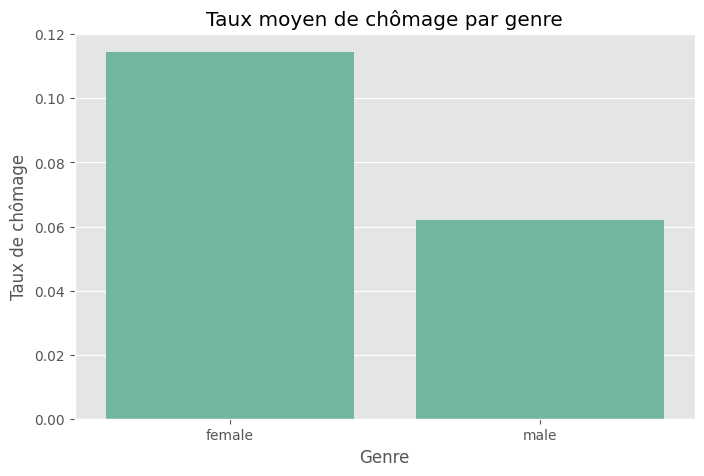

In [24]:
# VISUALISATION DU CHOMAGE PAR GENRE
#  1. CALCUL DES MOYENNES PAR GENRE
gender_unemp = (
    unemp_df
    # Groupe les données selon la colonne 'gender'
    .groupby('gender')['share_unemp']
    # Calcule le taux de chômage moyen pour chaque genre
    .mean()
    # Transforme le résultat en DataFrame pour faciliter le traçage
    .reset_index()
)

#  2. CRÉATION DU GRAPHIQUE
# Initialise une figure de 8 pouces de large et 5 pouces de haut
plt.figure(figsize=(8,5))

# Génère un graphique en barres avec Seaborn
ax = sns.barplot(
    data=gender_unemp,  # Source des données
    x='gender',         # Axe horizontal : les genres
    y='share_unemp'     # Axe vertical : le taux de chômage moyen
)
# 3. PERSONNALISATION DE L'AFFICHAGE

# Ajoute un titre principal au graphique
plt.title("Taux moyen de chômage par genre")
# Modifie le nom de l'axe vertical
plt.ylabel("Taux de chômage")
# Modifie le nom de l'axe horizontal
plt.xlabel("Genre")
# Affiche le graphique final à l'écran
plt.savefig("taux_chomage_genre.png", dpi=300, bbox_inches='tight') # le sauvegarde du graphique
plt.show()


### Interprètation

Les résultats montrent une disparité de genre dans le chômage des jeunes en Côte d’Ivoire. Les jeunes femmes présentent un niveau de vulnérabilité plus élevé que les hommes, ce qui peut refléter des barrières structurelles d’accès à l’emploi formel.

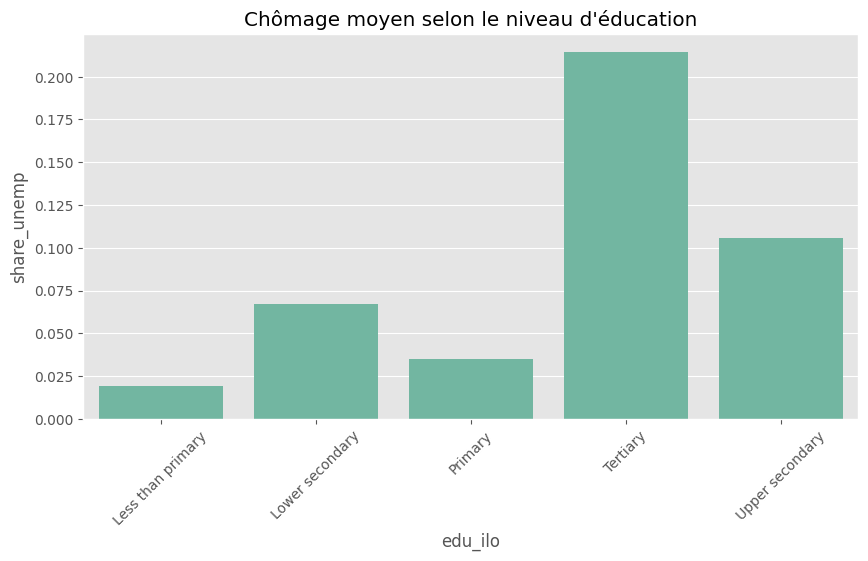

In [25]:
# Analyse éducation vs chômage
# --- 1. CALCUL DES MOYENNES PAR NIVEAU D'ÉDUCATION ---

edu_unemp = (
    unemp_df
    # Groupe les données selon la colonne du niveau d'éducation (norme BIT)
    .groupby('edu_ilo')['share_unemp']
    # Calcule le taux de chômage moyen pour chaque niveau
    .mean()
    # Transforme le résultat en DataFrame pour le graphique
    .reset_index()
)

# --- 2. CRÉATION DU GRAPHIQUE

# Initialise une figure de 10 pouces de large et 5 pouces de haut
plt.figure(figsize=(10,5))

# Génère un graphique en barres avec Seaborn
ax = sns.barplot(
    data=edu_unemp,   # Source des données
    x='edu_ilo',       # Axe horizontal : les niveaux d'éducation
    y='share_unemp'   # Axe vertical : le taux de chômage moyen
)

# --- 3. PERSONNALISATION ET AFFICHAGE

# Ajoute un titre au graphique
plt.title("Chômage moyen selon le niveau d'éducation")

# Incline les étiquettes de l'axe X à 45 degrés pour éviter qu'elles ne se chevauchent
plt.xticks(rotation=45)

# Affiche le graphique final à l'écran
plt.show()


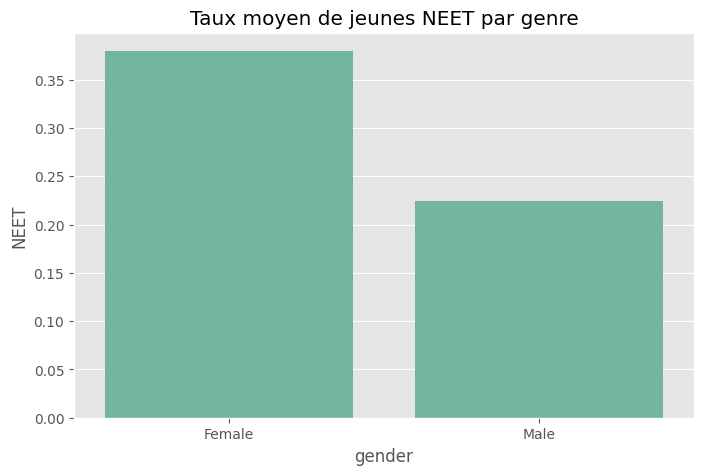

In [26]:
# ANALYSE DE NEET
# NEET qui signifie : Ni en emploi, ni en études, ni en formation
# --- 1. CALCUL DU TAUX DE NEET PAR GENRE ---
neet_gender = (
    inactive_df
    # Groupe les données sur l'inactivité selon la colonne 'gender'
    .groupby('gender')['neet_fc']
    # Calcule la part moyenne de jeunes NEET pour chaque genre
    .mean()
    .reset_index() # remet le tableau sous forme lisible
)

# --- 2. CRÉATION DU GRAPHIQUE ---
# Initialise une figure de 8 pouces de large et 5 pouces de haut
plt.figure(figsize=(8,5))
# Génère un graphique en barres avec Seaborn
sns.barplot(
    data=neet_gender,  # Source des données agrégées
    x='gender',         # Axe horizontal : les genres
    y='neet_fc'         # Axe vertical : le taux moyen de NEET
)

# --- 3. PERSONNALISATION ET AFFICHAGE ---
# Ajoute un titre descriptif au graphique
plt.title("Taux moyen de jeunes NEET par genre")
# Renomme l'axe vertical pour plus de clarté
plt.ylabel("NEET")
plt.savefig("neet_genre.png", dpi=300, bbox_inches='tight')
# Affiche le graphique final à l'écran
plt.show()

# Analyse de l'emploi formel et informel

L’économie informelle représente une part importante du marché du travail en Côte d’Ivoire. Cette section analyse la répartition des jeunes dans les secteurs formels et informels selon le genre et les secteurs économiques.

In [27]:
# Dataset à analyser
formality_df = datasets['Data_africa_formality_sectors.csv'].copy() # creation d'une copie
formality_df.head() # Afffichage de quelques lignes

,ccode,year,gender,age,age_group,broad_sector,formality,population
277200,CIV,2015,Female,15,15-24,Services,Informal,10226.0
277201,CIV,2015,Female,15,15-24,Services,Formal,74.0
277202,CIV,2015,Female,16,15-24,Services,Informal,9956.0
277203,CIV,2015,Female,16,15-24,Services,Formal,72.0
277204,CIV,2015,Female,17,15-24,Services,Informal,9638.0


In [28]:
formality_df['population'].sum() # Addition de toute les ligne de la population

np.float64(104454785.0)

In [29]:
# Verifions les catégories
# Affiche la liste des secteurs uniques présents dans les données
print("Secteurs :")
print(formality_df['formality'].unique())
# Affiche la liste des secteurs d'activité uniques présents dans les données
print("\nSecteurs d'activité :")
print(formality_df['broad_sector'].unique())
# Affiche la liste des tranches d'âge uniques présentes dans les données
print("\nTranches d'âge :")
print(formality_df['age_group'].unique())
# Affiche la liste des genres uniques présents dans les données
print("\nGenres :")
print(formality_df['gender'].unique())

Secteurs :
['Informal' 'Formal']

Secteurs d'activité :
['Services' 'Agriculture' 'Industry']

Tranches d'âge :
['15-24' '25-34' '35-44' '45-54' '55-64']

Genres :
['Female' 'Male']


Après avoir vérifier les catégories pours chaque variables, construisons les graphiques des répartitions des sectuers formels et informels

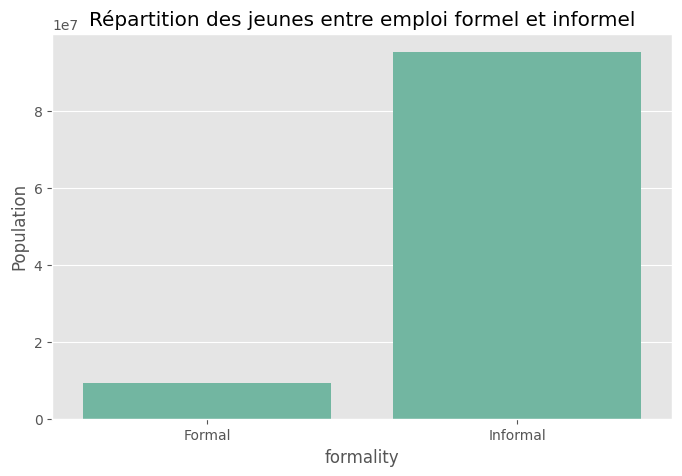

In [30]:
# Regroupe les données par type de formalité et calcule la population totale pour chaque groupe
formality_analysis = (
    formality_df
    .groupby('formality')['population']
    .sum()
    .reset_index() # Convertit le résultat en DataFrame pour faciliter le traçage du graphique
)

# Définit la taille de la fenêtre du graphique (8 pouces de large, 5 pouces de haut)
plt.figure(figsize=(8,5))

# Crée un diagramme en barres avec la variable 'formality' en abscisse et la 'population' en ordonnée
sns.barplot(
    data=formality_analysis, # jeu de données
    x='formality',           # axe des abscisses
    y='population'           # axe des ordonnées
)

# Ajoute un titre principal au graphique
plt.title("Répartition des jeunes entre emploi formel et informel")
# Ajoute une étiquette sur l'axe vertical pour indiquer la mesure (la population)
plt.ylabel("Population")
# Affiche le graphique final à l'écran
plt.show()

### Interprètation
Les résultats montrent une forte concentration des jeunes dans le secteur informel. Cette situation traduit la difficulté d’accès à des emplois stables et protégés, particulièrement pour les jeunes entrant sur le marché du travail.

# Analyse : Genre vs Informalité

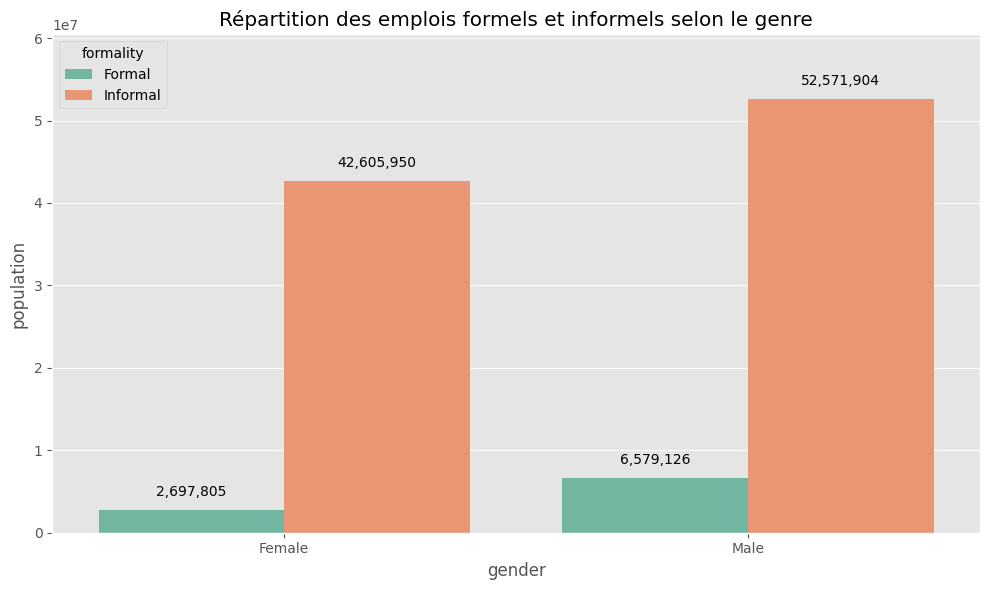

In [31]:
# Regroupe les données par genre et par type de formalité, puis calcule la population totale de chaque groupe
gender_formality = (
    formality_df
    .groupby(['gender', 'formality'])['population']
    .sum()
    .reset_index() # Convertit le résultat en DataFrame exploitable par Seaborn
)

# Définit la taille du graphique (10 pouces de largeur, 6 pouces de hauteur)
plt.figure(figsize=(10,6))

# Crée un diagramme en barres groupées (le genre en abscisse, la population en ordonnée, coloré selon la formalité)
ax = sns.barplot(
    data=gender_formality,
    x='gender',
    y='population',
    hue='formality'
)
# Parcourt chaque groupe de barres pour y ajouter les valeurs numériques exactes
for container in ax.containers:
  ax.bar_label(container,
               fmt='{:,.0f}', # Formate les nombres avec des virgules pour les milliers (ex: 1,234,567)
               padding=8)     # Ajoute un espace de 8 points entre le haut de la barre et le texte

# Ajoute un titre descriptif au graphique
plt.title("Répartition des emplois formels et informels selon le genre")
# Ajuste la limite de l'axe vertical à +15% du maximum pour laisser de la place aux étiquettes de texte
plt.ylim(0, gender_formality['population'].max() * 1.15)
# Ajuste automatiquement les marges pour éviter que les éléments ou textes ne soient coupés
plt.tight_layout()
# Affiche le graphique final
plt.savefig("formel_informel.png", dpi=300, bbox_inches='tight')
plt.show()

## Interprètation
Les hommes sont plus dans les deux secteurs que les femmes

# ANALYSE DU SECTEURS ECONOMIQUES

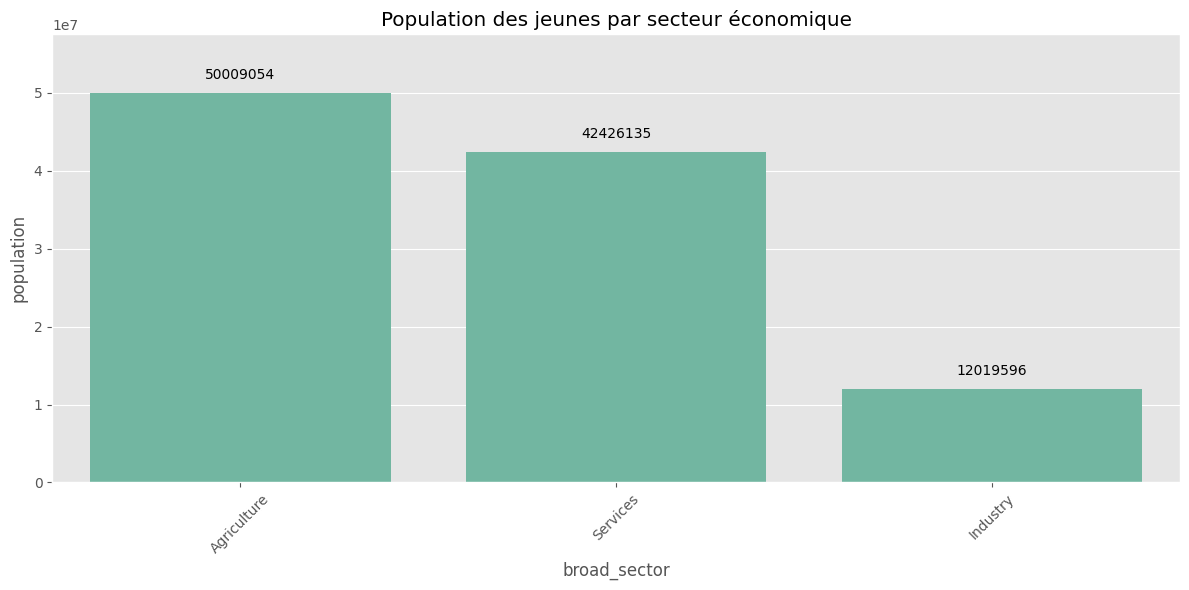

In [32]:
# Regroupe la population par secteur d'activité, trie par ordre décroissant et réinitialise l'index
sector_analysis = (
    formality_df # jeu de données
    .groupby('broad_sector')['population']
    .sum()
    .sort_values(ascending=False) # Trie les secteurs du plus peuplé au moins peuplé
    .reset_index()                # Transforme le résultat en DataFrame standard
)

# Définit la taille du graphique (12 pouces de largeur, 6 pouces de hauteur)
plt.figure(figsize=(12,6))

# Crée un diagramme en barres montrant la population pour chaque secteur économique
ax = sns.barplot(
    data=sector_analysis,
    x='broad_sector',
    y='population'
)

# Parcourt les barres pour afficher la valeur numérique exacte de la population au-dessus de chacune
for container in ax.containers:
  ax.bar_label(container,
               fmt='{:.0f}', # Formate les valeurs en nombres entiers sans décimales
               padding=8)    # Espace de 8 points entre le sommet de la barre et le texte

# Pivote les étiquettes de l'axe horizontal à 45 degrés pour éviter qu'elles ne se chevauchent
plt.xticks(rotation=45)
# Ajoute un titre explicite au graphique
plt.title("Population des jeunes par secteur économique")
# Ajuste la hauteur de l'axe vertical pour laisser de la place aux étiquettes de texte
plt.ylim(0, sector_analysis['population'].max() * 1.15)
# Ajuste automatiquement les marges pour que les étiquettes inclinées ne soient pas coupées
plt.tight_layout()
# Affiche le graphique final
plt.savefig("secteur_economique.png", dpi=300, bbox_inches='tight')
plt.show()

# Interprètation
Le secteur de l'agriculture est dominant, il absorbe

# Analyse des disparités territoriales : rural vs urbain
Les opportunités d’emploi diffèrent fortement entre les zones rurales et urbaines. Cette section étudie les disparités territoriales dans l’accès à l’emploi des jeunes.

In [33]:
# Preparation des données
geo_df = datasets['Data_employed_rural_urban.csv'].copy()
geo_df.head()

,ccode,year,gender,age,age_group,status,geo,pop_emp_geo
52800,CIV,2015,female,15,15-24,employed,rural,60271.0
52801,CIV,2015,female,15,15-24,employed,urban,58479.0
52802,CIV,2015,female,15,15-24,unemployed,rural,1039.0
52803,CIV,2015,female,15,15-24,unemployed,urban,4423.0
52804,CIV,2015,female,15,15-24,inactive,rural,27496.0


In [34]:
# Verifions les catégories
print('Les status sont :',geo_df['status'].unique())
print('Les Zones sont :',geo_df['geo'].unique())
print('L\'addition de la population est : ', geo_df['pop_emp_geo'].sum())

Les status sont : ['employed' 'unemployed' 'inactive' 'student']
Les Zones sont : ['rural' 'urban']
L'addition de la population est :  162080035.0


## Graphique : Population employée rural/urbain

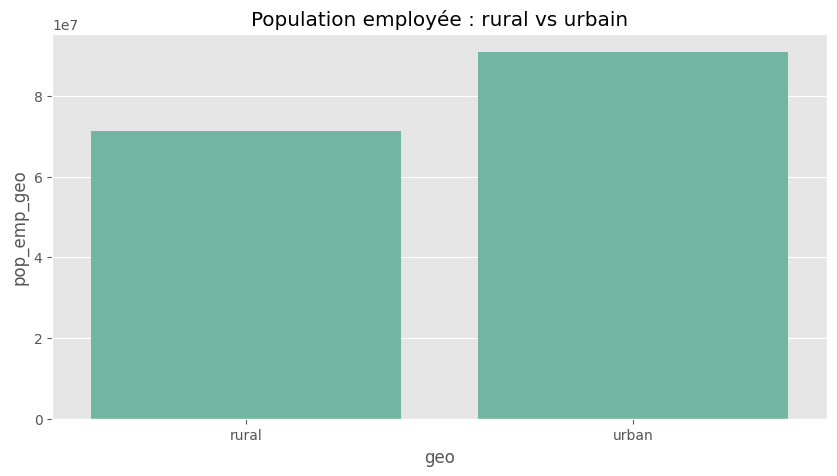

In [35]:
geo_analysis = (
    geo_df
    .groupby('geo')['pop_emp_geo']
    .sum()
    .reset_index()
)
plt.figure(figsize=(10,5))
sns.barplot(
    data=geo_analysis,
    x='geo',
    y='pop_emp_geo'
)
plt.title("Population employée : rural vs urbain")
plt.savefig("rural_urbain.png", dpi=300, bbox_inches='tight')
plt.show()

## Graphique : Genre + géographie

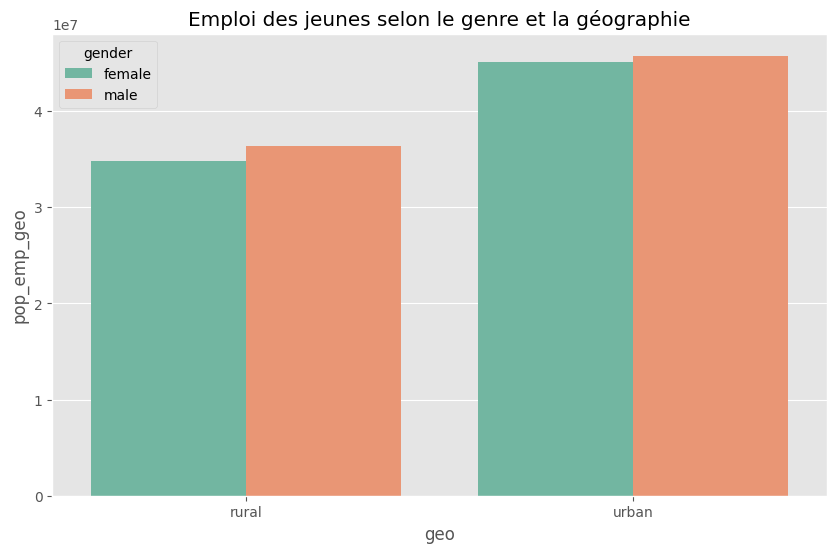

In [36]:
geo_gender = (
    geo_df
    .groupby(['geo', 'gender'])['pop_emp_geo']
    .sum()
    .reset_index()
)
plt.figure(figsize=(10,6))
sns.barplot(
    data=geo_gender,
    x='geo',
    y='pop_emp_geo',
    hue='gender'
)
plt.title("Emploi des jeunes selon le genre et la géographie")
plt.savefig("genre_géo.png", dpi=300, bbox_inches='tight')
plt.show()

# CAS PRATIQUE DE SIMULATION
Question : Que se passera t-il si l'emploi feminin augmentait de 10% ?

In [37]:
female_emp = geo_gender[
    geo_gender['gender'] == 'female']['pop_emp_geo'].sum()

scenario = female_emp * 1.10
print("Population féminine employée actuelle :", female_emp)
print("Population féminine employée après mise en place de politique :", scenario)

Population féminine employée actuelle : 79896663.0
Population féminine employée après mise en place de politique : 87886329.30000001


### Simulation politique
Une augmentation de 10 % de l’emploi féminin pourrait permettre une intégration significative des jeunes femmes dans l’économie active et réduire les inégalités structurelles sur le marché du travail.

# Analyse sectorielle approfondie

## Objectif :

identifier les secteurs qui absorbent les jeunes,
détecter les secteurs dominés par l’informel,
montrer les opportunités potentielles.

. Cette section identifie les secteurs économiques qui concentrent le plus d’emplois pour les jeunes ivoiriens et met en évidence les dynamiques de formalité et de vulnérabilité.

In [38]:
# Chargement des données
sector_df = datasets['Data_africa_sector_employed.csv'].copy()
sector_df.head()

,ccode,year,gender,age,broad_sector,sector21,population
138600,CIV,2015,Female,15,Services,Accommodation and food service activities,10300.0
138601,CIV,2015,Female,16,Services,Accommodation and food service activities,10028.0
138602,CIV,2015,Female,17,Services,Accommodation and food service activities,9708.0
138603,CIV,2015,Female,18,Services,Accommodation and food service activities,9320.0
138604,CIV,2015,Female,19,Services,Accommodation and food service activities,8892.0


In [39]:
print(sector_df['broad_sector'].unique())
print(sector_df['year'].unique())
print("\n")
print(sector_df['sector21'].unique()[:20])

['Services' 'Agriculture' 'Industry']
[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]


['Accommodation and food service activities'
 'Activities of extraterritorial organizations and bodies'
 'Activities of households as employers; undifferentiated goods- and services-producing activities of households for own use'
 'Administrative and support service activities'
 'Agriculture; forestry and fishing' 'Arts, entertainment and recreation'
 'Construction' 'Education'
 'Electricity; gas, steam and air conditioning supply'
 'Financial and insurance activities'
 'Human health and social work activities' 'Information and communication'
 'Manufacturing' 'Mining and quarrying' 'Other service activities'
 'Professional, scientific and technical activities'
 'Public administration and defence; compulsory social security'
 'Real estate activities' 'Transportation and storage'
 'Water supply; sewerage, waste management and remediation activities']


# Top secteur employeur

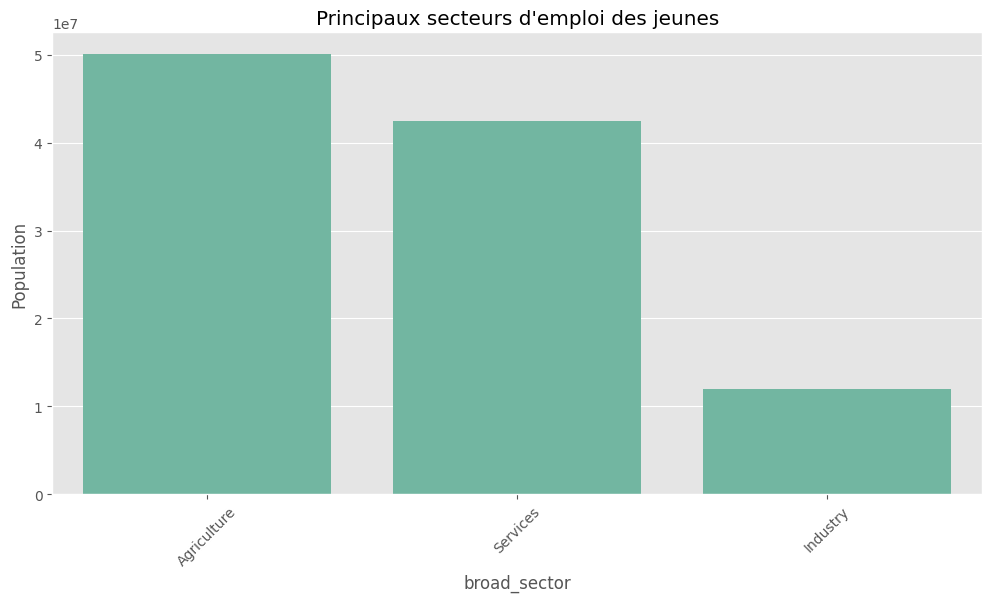

In [40]:
top_sectors = (
    sector_df
    .groupby('broad_sector')['population']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_sectors,
    x='broad_sector',
    y='population'
)
plt.xticks(rotation=45)
plt.title("Principaux secteurs d'emploi des jeunes")
plt.ylabel("Population")
plt.savefig("secteur_emploi_jeune.png", dpi=300, bbox_inches='tight')
plt.show()

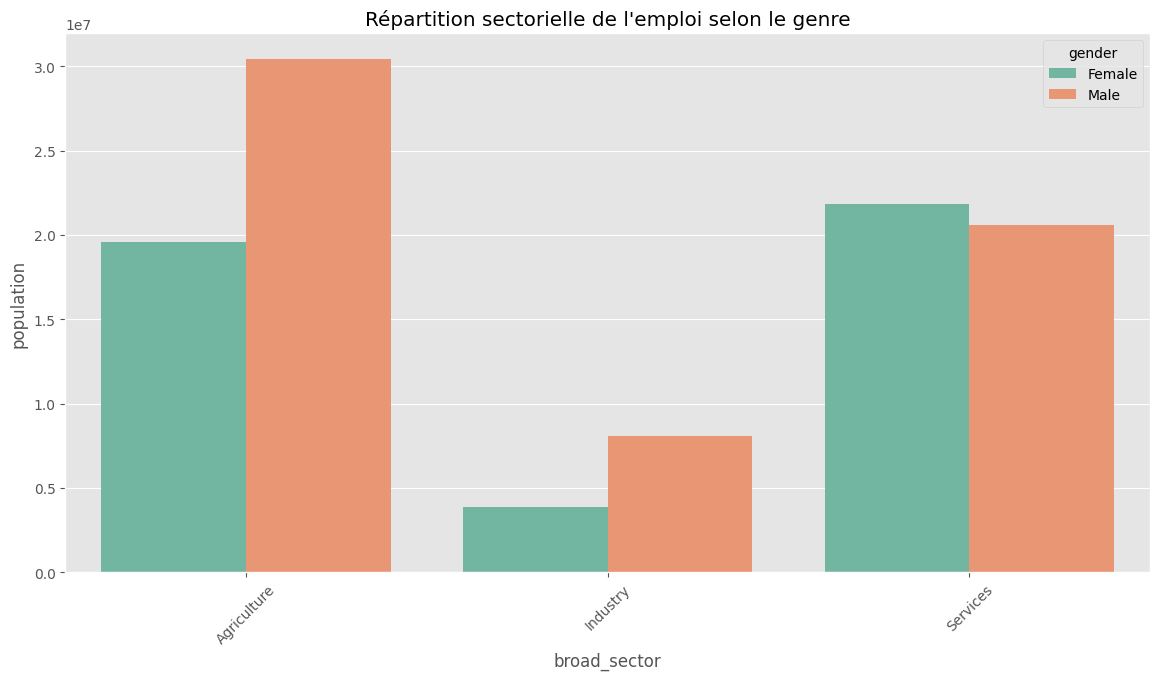

In [41]:
# Secteur selon le genre
sector_gender = (
    sector_df
    .groupby(['broad_sector', 'gender'])['population']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,7))

sns.barplot(
    data=sector_gender,
    x='broad_sector',
    y='population',
    hue='gender'
)

plt.xticks(rotation=45)
plt.title("Répartition sectorielle de l'emploi selon le genre")
plt.savefig("emlpoi_selon_genre.png", dpi=300, bbox_inches='tight')
plt.show()

# CREATION D'UN INDICE DE VULNERABILITÉ

Creation d'indice de vulnérabilité basé sur le chômage, inactivité et le NEET

* Pour faire cela nous allons fusionner deux datasets qui sont [unemp_df,
    inactive_df]

In [42]:
unemp_df.columns

Index(['ccode', 'year', 'edu_ilo', 'age_group', 'gender', 'share_unemp',
       'share_inact'],
      dtype='object')

In [43]:
inactive_df.columns

Index(['ccode', 'year', 'gender', 'age_group', 'edu_ilo', 'neet_fc'], dtype='object')

In [44]:
inactive_df['neet_fc'].count()

np.int64(330)

In [45]:
vulnerability_df = pd.merge(
    unemp_df,
    inactive_df,
    on=['ccode', 'year', 'gender', 'age_group', 'edu_ilo'],
    how='left'
)
#Affichage de l'entête (5 lignes)
vulnerability_df.head()

,ccode,year,edu_ilo,age_group,gender,share_unemp,share_inact,neet_fc
0,CIV,2015,Less than primary,15-24,female,0.022517,0.408283,NaN
1,CIV,2016,Less than primary,15-24,female,0.010740,0.454940,NaN
2,CIV,2017,Less than primary,15-24,female,0.033620,0.622550,NaN
3,CIV,2018,Less than primary,15-24,female,0.032850,0.547630,NaN
4,CIV,2019,Less than primary,15-24,female,0.032080,0.472710,NaN


In [46]:
vulnerability_df['neet_fc'].count()

np.int64(0)

In [47]:
# Construction du score
vulnerability_df['vulnerability_score'] = (
    vulnerability_df['share_unemp']
    + vulnerability_df['share_inact']
   # + vulnerability_df['neet_fc']
) / 2

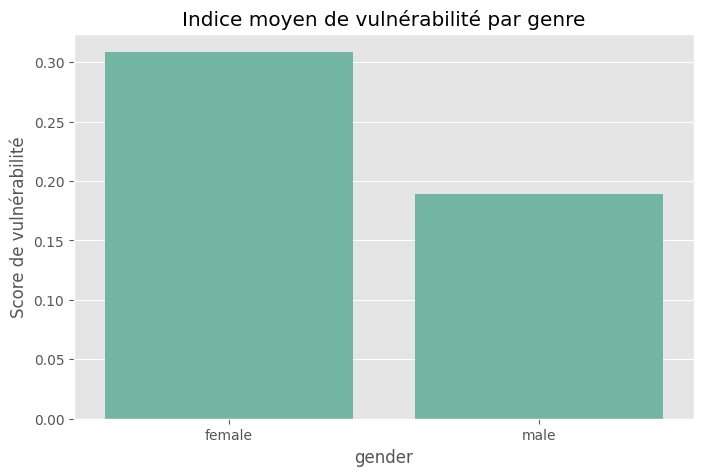

In [48]:
# Analyse par genre
vul_gender = (
    vulnerability_df
    .groupby('gender')['vulnerability_score']
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))
sns.barplot(
    data=vul_gender,
    x='gender',
    y='vulnerability_score'
)
plt.title("Indice moyen de vulnérabilité par genre")
plt.ylabel("Score de vulnérabilité")
plt.savefig("vulnerabilite_par_genre.png", dpi=300, bbox_inches='tight')
plt.show()

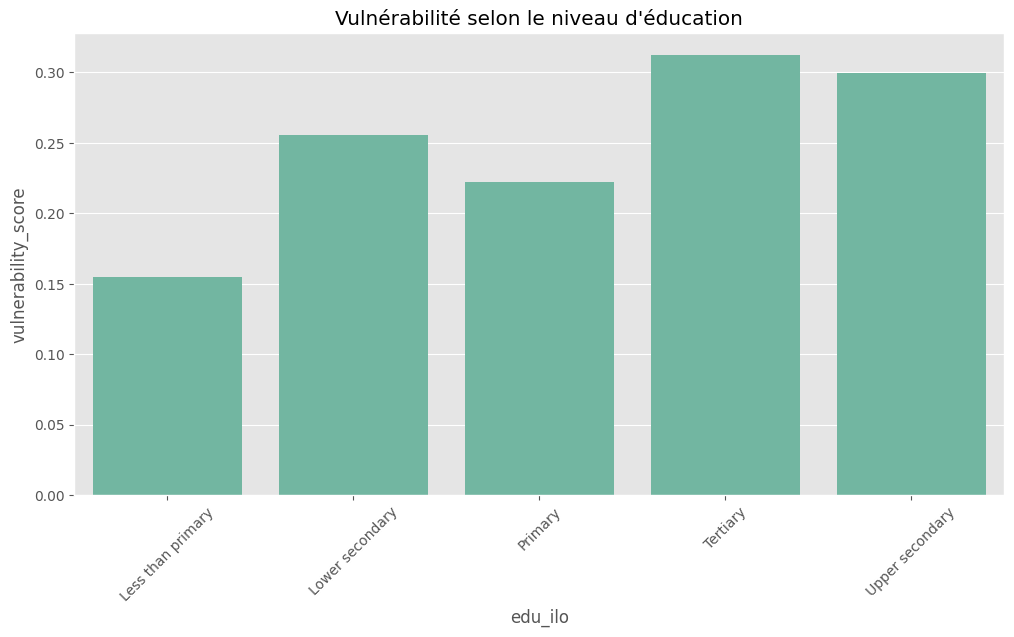

In [49]:
# Vulnerabilité selon l'éducation
vul_edu = (
    vulnerability_df
    .groupby('edu_ilo')['vulnerability_score']
    .mean()
    .reset_index()
)
plt.figure(figsize=(12,6))
sns.barplot(
    data=vul_edu,
    x='edu_ilo',
    y='vulnerability_score'
)
plt.xticks(rotation=45)
plt.title("Vulnérabilité selon le niveau d'éducation")
plt.savefig("niveau_education.png", dpi=300, bbox_inches='tight')
plt.show()

## Interprètation
Faible éducation = forte vulnerabilité

# Recommandations pour les politiques publiques

Les analyses réalisées mettent en évidence plusieurs défis structurels liés à l’emploi des jeunes en Côte d’Ivoire.

## Recommandations principales

### 1. Renforcer l’accès des jeunes femmes à l’emploi formel
- Développer des programmes ciblés d’insertion professionnelle ;
- Soutenir l’entrepreneuriat féminin ;
- Réduire les barrières d’accès au marché du travail.

### 2. Investir davantage dans l’éducation secondaire et technique
- Renforcer les formations professionnelles ;
- Adapter les curricula aux besoins du marché du travail ;
- Développer les compétences numériques.

### 3. Réduire les disparités territoriales
- Soutenir les infrastructures économiques rurales ;
- Encourager les investissements hors des grands centres urbains.

### 4. Formaliser progressivement l’économie informelle
- Faciliter l’accès des jeunes aux emplois protégés ;
- Renforcer les mécanismes de protection sociale.

# Conclusion

Cette étude met en évidence l’existence de fortes disparités de genre, d’éducation et de localisation dans l’accès à l’emploi des jeunes en Côte d’Ivoire.

Les jeunes femmes, les populations faiblement qualifiées et les jeunes vivant en zones rurales apparaissent particulièrement vulnérables face au chômage, à l’inactivité et à l’emploi informel.

Les résultats soulignent la nécessité de politiques publiques ciblées afin de favoriser une croissance inclusive et durable du marché du travail ivoirien.